In [574]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [575]:
#import data from /Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/processed/ProcessedObservedData.csv
data = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\data\processed\ProcessedObservedData.csv')
#filter by opDiv CDC
data = data[data['OpDiv'] == 'CDC']
data.drop(columns=['curr_date', 'OpDiv'], inplace=True)
# Rename the index to 'date' since 'obs_date' is now the index
data.rename(columns={'obs_date': 'date'}, inplace=True)
data.reset_index(drop=True, inplace=True)
data.head(10)
# Create a copy of the relevant columns to avoid SettingWithCopyWarning

data.head(10)

,indicator,API_UserName,date,observations
0,146.71.50.198,00818860012482918321,2025-01-01,1
1,149.36.49.225,00818860012482918321,2025-01-01,28
2,162.142.125.242,00818860012482918321,2025-01-01,3
3,162.142.125.247,00818860012482918321,2025-01-01,2
4,162.142.125.255,00818860012482918321,2025-01-01,3
5,185.230.63.171,00818860012482918321,2025-01-01,6
6,23.26.221.12,00818860012482918321,2025-01-01,49
7,23.26.221.2,00818860012482918321,2025-01-01,51
8,23.26.221.4,00818860012482918321,2025-01-01,36
9,34.160.111.145,00818860012482918321,2025-01-01,4


In [576]:
data['date'] = pd.to_datetime(data['date'])

# Define ranges for combinations
all_users = data['API_UserName'].unique()  # Unique API_UserName
all_indicators = data['indicator'].unique()  # Unique indicators
all_dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')  # Full year of 2025

# Create all combinations
all_combinations = pd.MultiIndex.from_product(
    [all_users, all_dates, all_indicators],
    names=['API_UserName', 'date', 'indicator']
).to_frame(index=False)

# Merge with the existing data
merged = all_combinations.merge(data, how='left', on=['API_UserName', 'date', 'indicator'])

# Fill missing values in 'observations' with 0 (not seen)
merged['observations'] = merged['observations'].fillna(0).astype(int)

# Display the first few rows of the merged dataset
print(merged.head())

           API_UserName       date        indicator  observations
0  00818860012482918321 2025-01-01    146.71.50.198             1
1  00818860012482918321 2025-01-01    149.36.49.225            28
2  00818860012482918321 2025-01-01  162.142.125.242             3
3  00818860012482918321 2025-01-01  162.142.125.247             2
4  00818860012482918321 2025-01-01  162.142.125.255             3


In [577]:
unfiltered_records = data[data['indicator'] == '146.71.50.198']
unfiltered_records

,indicator,API_UserName,date,observations
0,146.71.50.198,00818860012482918321,2025-01-01,1
62,146.71.50.198,00818860012482918321,2025-01-05,2
90,146.71.50.198,00818860012482918321,2025-01-07,1
138,146.71.50.198,00818860012482918321,2025-01-09,2
191,146.71.50.198,00818860012482918321,2025-01-13,1
245,146.71.50.198,00818860012482918321,2025-01-16,3
313,146.71.50.198,00818860012482918321,2025-01-21,1
388,146.71.50.198,00818860012482918321,2025-01-24,1
400,146.71.50.198,00818860012482918321,2025-01-26,2
407,146.71.50.198,00818860012482918321,2025-01-27,1


In [578]:
filtered_records = merged[merged['indicator'] == '146.71.50.198']
filtered_records

,API_UserName,date,indicator,observations
0,00818860012482918321,2025-01-01,146.71.50.198,1
196,00818860012482918321,2025-01-02,146.71.50.198,0
392,00818860012482918321,2025-01-03,146.71.50.198,0
588,00818860012482918321,2025-01-04,146.71.50.198,0
784,00818860012482918321,2025-01-05,146.71.50.198,2
...,...,...,...,...
70560,00818860012482918321,2025-12-27,146.71.50.198,0
70756,00818860012482918321,2025-12-28,146.71.50.198,0
70952,00818860012482918321,2025-12-29,146.71.50.198,0
71148,00818860012482918321,2025-12-30,146.71.50.198,0


In [579]:
# Convert the 'date' column to datetime format
merged['date'] = pd.to_datetime(merged['date'])

# Extract day of the week (0=Monday, 6=Sunday)
merged['dayofweek'] = merged['date'].dt.dayofweek

# Determine if the day is a weekend (Saturday=5, Sunday=6)
merged['is_weekend'] = merged['dayofweek'].isin([5, 6])

# Extract additional features if needed
merged['day'] = merged['date'].dt.day
merged['month'] = merged['date'].dt.month


In [580]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71540 entries, 0 to 71539
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   API_UserName  71540 non-null  object        
 1   date          71540 non-null  datetime64[ns]
 2   indicator     71540 non-null  object        
 3   observations  71540 non-null  int64         
 4   dayofweek     71540 non-null  int32         
 5   is_weekend    71540 non-null  bool          
 6   day           71540 non-null  int32         
 7   month         71540 non-null  int32         
dtypes: bool(1), datetime64[ns](1), int32(3), int64(1), object(2)
memory usage: 3.1+ MB


In [581]:
# Exclude rows with observations = 0 for outlier detection
non_zero_observations = merged[merged['observations'] > 0]

# Calculate Q1 (25th percentile) and Q3 (75th percentile) for non-zero observations
Q1 = non_zero_observations['observations'].quantile(0.25)
Q3 = non_zero_observations['observations'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = non_zero_observations[
    (non_zero_observations['observations'] < lower_bound) |
    (non_zero_observations['observations'] > upper_bound)
]

# Keep only non-outlier rows
non_outliers = non_zero_observations[
    (non_zero_observations['observations'] >= lower_bound) &
    (non_zero_observations['observations'] <= upper_bound)
]

# Recombine with rows where observations = 0
data_no_outliers = pd.concat([non_outliers, merged[merged['observations'] == 0]])

# Reset index
data_no_outliers.reset_index(drop=True, inplace=True)

# Print summary
print(f"Number of outliers removed: {len(outliers)}")
print(f"Original data size: {len(merged)}")
print(f"Data size after removing outliers: {len(data_no_outliers)}")

Number of outliers removed: 345
Original data size: 71540
Data size after removing outliers: 71195


In [582]:
non_zero_observations = data_no_outliers[data_no_outliers['observations'] > 0]
features = non_zero_observations[['observations']]

In [583]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

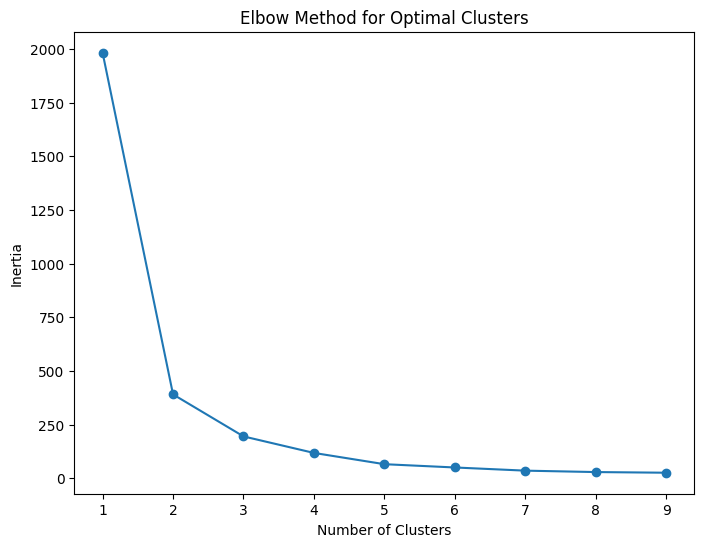

In [584]:
# Calculate the sum of squared distances (inertia) for different cluster counts
inertia = []
for k in range(1, 10):  # Test cluster sizes from 1 to 9
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, 10), inertia, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [585]:
optimal_k = 3

# Apply KMeans clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
non_zero_observations['cluster'] = kmeans.fit_predict(scaled_features)

# Merge the clusters back into the full dataset
data_no_outliers = data_no_outliers.merge(
    non_zero_observations[['cluster']], 
    how='left', 
    left_index=True, 
    right_index=True
)

import plotly.express as px

# Create an interactive scatter plot using plotly
fig = px.scatter(
    non_zero_observations,
    x=non_zero_observations.index,  # Use index as x-axis
    y='observations',  # Observations as y-axis
    color='cluster',  # Color by cluster
    title='KMeans Clustering on Observations',
    labels={'x': 'Index', 'observations': 'Observations'},
    color_continuous_scale='Viridis'
)

# Show the interactive plot
fig.show()

# Display cluster centers
print("Cluster Centers:")
print(kmeans.cluster_centers_)

C:\Users\jaskew\AppData\Local\Temp\ipykernel_46564\1608986163.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Cluster Centers:
[[-0.49445357]
 [ 2.57338879]
 [ 0.42595024]]


In [586]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(scaled_features, kmeans.labels_)
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.6966988107865114


In [587]:
data_no_outliers.head(10)

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,cluster
0,00818860012482918321,2025-01-01,146.71.50.198,1,2,False,1,1,0.0
1,00818860012482918321,2025-01-01,149.36.49.225,28,2,False,1,1,1.0
2,00818860012482918321,2025-01-01,162.142.125.242,3,2,False,1,1,0.0
3,00818860012482918321,2025-01-01,162.142.125.247,2,2,False,1,1,0.0
4,00818860012482918321,2025-01-01,162.142.125.255,3,2,False,1,1,0.0
5,00818860012482918321,2025-01-01,185.230.63.171,6,2,False,1,1,2.0
6,00818860012482918321,2025-01-01,34.160.111.145,4,2,False,1,1,0.0
7,00818860012482918321,2025-01-02,162.142.125.242,2,3,False,2,1,0.0
8,00818860012482918321,2025-01-02,162.142.125.247,2,3,False,2,1,0.0
9,00818860012482918321,2025-01-02,162.142.125.255,1,3,False,2,1,0.0


In [588]:
#set nan clusters to -1
data_no_outliers['cluster'] = data_no_outliers['cluster'].fillna(-1)
# seen = observation > -1
data_no_outliers['seen'] = np.where(data_no_outliers['cluster'] > -1, 1, 0)


In [589]:
records = data_no_outliers[data_no_outliers['indicator'] == '149.36.49.225']
records


,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,cluster,seen
1,00818860012482918321,2025-01-01,149.36.49.225,28,2,False,1,1,1.0,1
185,00818860012482918321,2025-01-14,149.36.49.225,1,1,False,14,1,0.0,1
470,00818860012482918321,2025-01-31,149.36.49.225,1,4,False,31,1,0.0,1
1070,00818860012482918321,2025-03-03,149.36.49.225,3,0,False,3,3,0.0,1
1877,00818860012482918321,2025-04-10,149.36.49.225,3,3,False,10,4,0.0,1
...,...,...,...,...,...,...,...,...,...,...
70216,00818860012482918321,2025-12-27,149.36.49.225,0,5,True,27,12,-1.0,0
70412,00818860012482918321,2025-12-28,149.36.49.225,0,6,True,28,12,-1.0,0
70608,00818860012482918321,2025-12-29,149.36.49.225,0,0,False,29,12,-1.0,0
70804,00818860012482918321,2025-12-30,149.36.49.225,0,1,False,30,12,-1.0,0


In [590]:
data_no_outliers.to_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\ClusteredData.csv', index=False)